# Fast Hankel matrix–vector multiplication — validation

Validates the FFT-based Hankel matvec in `ga/reducers/hankel.py`:

1. correctness — fast matvec equals the dense Hankel matvec;
2. the `reduce_fft_truncate` bug we found (`dtype='float32'` default loses ~6 digits);
3. scaling — `O(k log k)` fast vs `O(k²)` dense;
4. `msvdreduce_fast` (FFT/Lanczos partial SVD) matches the dense `msvdreduce_fixed`.

Theory: `docs/derivations/05-fast-hankel-matvec.md`.

In [1]:
%matplotlib inline
import sys, os, time
try:
    import ga  # noqa
except ModuleNotFoundError:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from ga.reducers.hankel import (FastHankelProduct, reduce_fft_truncate, reduce_svd_truncate,
                                blkhankel, BlockHankelOperator, msvdreduce_fixed, msvdreduce_fast)
from ga.filters.tib import (null_basis_realization, build_tib_from_directions,
                            mimo_poles_to_ir, krylov_basis, poles_chebyshev_roots)
rng = np.random.default_rng(0)

## 1. The fast matvec is correct

`FastHankelProduct` (SISO) implements the *triangular* single-arg Hankel `la.hankel(h)`,
and the fully-populated `BlockHankelOperator` matches the dense block `blkhankel` —
both to machine precision.

In [2]:
# SISO: FastHankelProduct == triangular Hankel la.hankel(h)
N = 64
h = rng.standard_normal(N); x = rng.standard_normal(N)
err_tri = np.max(np.abs(FastHankelProduct(h, dtype='float64') @ x - la.hankel(h) @ x))

# MIMO: BlockHankelOperator == dense blkhankel (matvec and rmatvec)
p, q, L = 3, 2, 80; k = (L + 1)//2
ir = rng.standard_normal((p, q, L))
op = BlockHankelOperator(ir, k); H = blkhankel(ir)
xv = rng.standard_normal(q*k); yv = rng.standard_normal(p*k)
err_mv  = np.max(np.abs(op @ xv  - H @ xv))
err_rmv = np.max(np.abs(op.T @ yv - H.T @ yv))

print(f"FastHankelProduct vs triangular Hankel : max|Δ| = {err_tri:.1e}")
print(f"BlockHankelOperator matvec  vs blkhankel: max|Δ| = {err_mv:.1e}")
print(f"BlockHankelOperator rmatvec vs blkhankel: max|Δ| = {err_rmv:.1e}")

FastHankelProduct vs triangular Hankel : max|Δ| = 7.1e-15
BlockHankelOperator matvec  vs blkhankel: max|Δ| = 7.1e-15
BlockHankelOperator rmatvec vs blkhankel: max|Δ| = 1.4e-14


## 2. The `reduce_fft_truncate` bug: `dtype='float32'`

`FastHankelProduct` defaults to `dtype='float32'`. The FFT itself runs in float64, but
`eigsh` trusts the declared dtype and iterates in single precision — costing ~6 digits.
Declaring float64 (or comparing to the dense `reduce_svd_truncate`) shows the gap.

In [3]:
# known all-pole SISO system
n = 6
poles = np.sort(rng.uniform(0.1, 0.85, n))
den = np.array([1.0])
for lam in poles:
    den = np.convolve(den, [1.0, -lam])
hh = np.zeros(300); hh[0] = 1.0
for kk in range(1, len(hh)):
    hh[kk] = -sum(den[j]*hh[kk-j] for j in range(1, min(kk, n)+1))
h_pos = hh[1:]
t = np.sort(poles)

lam_fft = np.sort(np.real(reduce_fft_truncate(h_pos, n)))           # float32 default
# same code path, but float64 operator:
from scipy.sparse.linalg import eigsh
op64 = FastHankelProduct(h_pos, dtype='float64')
ev, V = eigsh(op64, n, which='LM'); j = np.argsort(np.abs(ev))[::-1]
v, _ = la.qr(V[:, j]); A = v.T[:n, 1:] @ v[:-1, :n]
lam_fft64 = np.sort(np.real(la.eig(A)[0]))
lam_svd = np.sort(np.real(reduce_svd_truncate(h_pos, n)))

print(f"reduce_fft_truncate (float32 default)  max|Δ| = {np.max(np.abs(lam_fft   - t)):.2e}   <-- bug")
print(f"same, float64 operator                 max|Δ| = {np.max(np.abs(lam_fft64 - t)):.2e}")
print(f"dense reduce_svd_truncate              max|Δ| = {np.max(np.abs(lam_svd   - t)):.2e}")

reduce_fft_truncate (float32 default)  max|Δ| = 2.33e-04   <-- bug
same, float64 operator                 max|Δ| = 3.66e-07
dense reduce_svd_truncate              max|Δ| = 1.73e-07


## 3. Scaling: `O(k log k)` vs `O(k²)`

Average matvec time for the fast operator vs the dense Hankel as `k` grows.

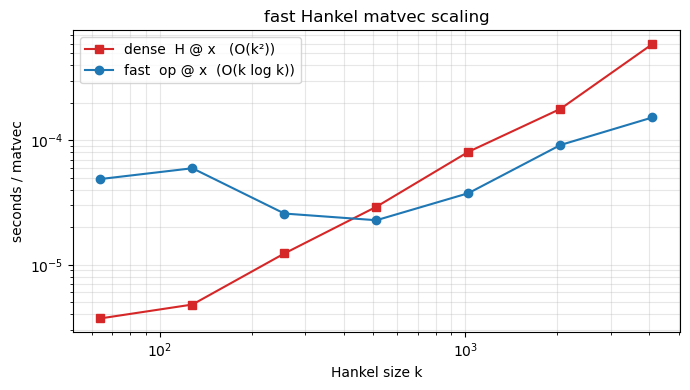

at k=4096: dense 0.6 ms  vs  fast 0.15 ms  (4x)


In [4]:
ks = [64, 128, 256, 512, 1024, 2048, 4096]
fast_t, dense_t = [], []
for kk in ks:
    hk = rng.standard_normal((1, 1, 2*kk))
    opk = BlockHankelOperator(hk, kk); Hk = blkhankel(hk); xk = rng.standard_normal(kk)
    opk @ xk  # warm up
    t0 = time.perf_counter()
    for _ in range(20): opk @ xk
    fast_t.append((time.perf_counter() - t0)/20)
    t0 = time.perf_counter()
    for _ in range(20): Hk @ xk
    dense_t.append((time.perf_counter() - t0)/20)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(ks, dense_t, "C3s-", label="dense  H @ x   (O(k²))")
ax.loglog(ks, fast_t, "C0o-", label="fast  op @ x  (O(k log k))")
ax.set_xlabel("Hankel size k"); ax.set_ylabel("seconds / matvec"); ax.legend()
ax.set_title("fast Hankel matvec scaling"); ax.grid(True, which="both", alpha=0.3)
fig.tight_layout(); plt.show()
print(f"at k={ks[-1]}: dense {dense_t[-1]*1e3:.1f} ms  vs  fast {fast_t[-1]*1e3:.2f} ms"
      f"  ({dense_t[-1]/fast_t[-1]:.0f}x)")

## 4. `msvdreduce_fast` matches the dense `msvdreduce_fixed`

`msvdreduce_fast` computes the partial Hankel SVD by Lanczos (`svds`) on the
`BlockHankelOperator` — never forming the dense matrix — then runs the same
shift + null-vector deflation. On a known MIMO TIB system it recovers the same poles
and transfer function as the dense path.

In [5]:
n, q, p, L = 6, 2, 3, 80
poles0 = poles_chebyshev_roots(n, 0.0, 0.85)
V0 = rng.standard_normal((q, n)); V0 /= np.linalg.norm(V0, axis=0)
C0 = rng.standard_normal((p, n))
ir0 = np.real(mimo_poles_to_ir(poles0, V0, C0, L))
t = np.sort(poles0)

def rebuild_relerr(w, y):
    sysr = build_tib_from_directions(np.real(w), np.real(y))
    A, B = sysr.A(dense=True), sysr.B(dense=True)
    K = np.asarray(krylov_basis(A, B, L)).reshape(n, -1)
    C = np.real(ir0.reshape(p, -1) @ np.linalg.pinv(K))
    ir = np.real(np.tensordot(C, np.asarray(krylov_basis(A, B, L)), (-1, 0)))
    return np.linalg.norm(ir - ir0)/np.linalg.norm(ir0)

wf, yf = msvdreduce_fast(ir0, n)
wd, yd = msvdreduce_fixed(ir0, n)
print(f"msvdreduce_fast   poles max|Δ| = {np.max(np.abs(np.sort(np.real(wf)) - t)):.1e}   IR rel err = {rebuild_relerr(wf, yf):.1e}")
print(f"msvdreduce_fixed  poles max|Δ| = {np.max(np.abs(np.sort(np.real(wd)) - t)):.1e}   IR rel err = {rebuild_relerr(wd, yd):.1e}")

msvdreduce_fast   poles max|Δ| = 2.3e-15   IR rel err = 1.9e-06
msvdreduce_fixed  poles max|Δ| = 4.9e-15   IR rel err = 1.9e-06


**Takeaways**

- The FFT Hankel matvec (`FastHankelProduct`, `BlockHankelOperator`) is exact to
  machine precision and scales as `O(k log k)` — orders of magnitude faster than dense
  for long impulse responses.
- `reduce_fft_truncate` is buggy: its `FastHankelProduct` defaults to `float32`, so
  `eigsh` loses ~6 digits (and it inherits the triangular-Hankel defect). Use float64.
- `msvdreduce_fast` is the corrected fast path — Lanczos partial SVD on the operator,
  then the `msvdreduce_fixed` shift + deflation — and matches the dense result.

In [6]:
wf

array([0.53499809+0.j, 0.72552038+0.j, 0.83551848+0.j, 0.31500191+0.j,
       0.12447962+0.j, 0.01448152+0.j])

In [7]:
wd

array([0.53499809+0.j, 0.72552038+0.j, 0.83551848+0.j, 0.31500191+0.j,
       0.12447962+0.j, 0.01448152+0.j])

In [8]:
yf

array([[ 0.03417391+0.j,  0.98198247+0.j, -0.8623872 +0.j,
         0.80665587+0.j,  0.95020293+0.j, -0.45530138+0.j],
       [-0.9994159 +0.j, -0.18897201+0.j, -0.50624926+0.j,
         0.59102142+0.j, -0.31163181+0.j, -0.89033738+0.j]])

In [9]:
yd

array([[-0.03417391+0.j,  0.98198247+0.j, -0.8623872 +0.j,
         0.80665587+0.j, -0.95020293+0.j,  0.45530138+0.j],
       [ 0.9994159 +0.j, -0.18897201+0.j, -0.50624926+0.j,
         0.59102142+0.j,  0.31163181+0.j,  0.89033738+0.j]])